# Fuel Price Features — Exploratory Analysis & Feature Engineering
## Repsol Capstone Project — Sprint 2 (Extension)

**Goal:** Process daily provincial fuel prices (2023–2025), aggregate to monthly national + regional level,
explore the price ↔ biodiesel demand relationship, and generate price features for model retraining.

**Inputs:**
- `data/raw/precios_combustibles_2023/24/25.csv` — daily price per province × product (PAI + PVP)
- `data/processed/biodiesel_targets.csv` — monthly biodiesel demand per target region

**Outputs:**
- `data/processed/price_features.csv` — monthly price features (national + regional, all products)

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

NOTEBOOK_DIR  = Path().resolve()
REPO_ROOT     = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
FIGS          = REPO_ROOT / 'reports' / 'figures'

# Province → Region mapping (only 4 target regions + Nacional)
REGION_MAP = {
    'Madrid':              'Madrid',
    'Barcelona':           'Cataluña',
    'Girona':              'Cataluña',
    'Lleida':              'Cataluña',
    'Tarragona':           'Cataluña',
    'Almería':             'Andalucía',
    'Cádiz':               'Andalucía',
    'Córdoba':             'Andalucía',
    'Granada':             'Andalucía',
    'Huelva':              'Andalucía',
    'Jaén':                'Andalucía',
    'Málaga':              'Andalucía',
    'Sevilla':             'Andalucía',
    'Alicante/Alacant':    'Valencia',
    'Castellón/Castelló':  'Valencia',
    'Valencia/València':   'Valencia',
}

# Short names for the 4 fuel products
PRODUCT_MAP = {
    'Gasolina 95 E5':    'gasolina95',
    'Gasolina 98 E5':    'gasolina98',
    'Gasóleo A habitual':'gasoleo_a',
    'Gasóleo Premium':   'gasoleo_prem',
}

print('Setup complete.')

Setup complete.


## 1. Load & Clean Raw Price Data

### What?
Combine 3 annual CSV files. The files use semicolon separators and comma decimal notation.

### Why?
Daily granularity (~75k rows/year × 3 years = ~227k rows) will be aggregated to monthly averages.
We need both PAI (cost price) and PVP (consumer price) as they capture different economic signals.

In [2]:
frames = []
for yr in [2023, 2024, 2025]:
    df = pd.read_csv(DATA_INPUTS   / f'precios_combustibles_{yr}.csv', sep=';', decimal=',')
    frames.append(df)
    print(f'{yr}: {df.shape[0]:,} rows')

df_raw = pd.concat(frames, ignore_index=True)

# Rename columns to clean short names
df_raw.columns = ['Fecha', 'Provincia', 'Producto', 'PAI', 'PVP']
df_raw['Fecha'] = pd.to_datetime(df_raw['Fecha'])
df_raw['Producto_short'] = df_raw['Producto'].map(PRODUCT_MAP)

print(f'\nTotal rows: {len(df_raw):,}')
print(f'Date range: {df_raw["Fecha"].min().date()} → {df_raw["Fecha"].max().date()}')
print(f'\nNull check:')
print(df_raw[['PAI','PVP']].isnull().sum())
df_raw.head(3)

2023: 75,553 rows
2024: 75,762 rows
2025: 75,524 rows

Total rows: 226,839
Date range: 2023-01-01 → 2025-12-31

Null check:
PAI    0
PVP    0
dtype: int64


,Fecha,Provincia,Producto,PAI,PVP,Producto_short
0,2023-01-01,Albacete,Gasolina 95 E5,0.859,1.611,gasolina95
1,2023-01-01,Albacete,Gasolina 98 E5,0.967,1.779,gasolina98
2,2023-01-01,Albacete,Gasóleo A habitual,1.022,1.695,gasoleo_a


## 2. Monthly Aggregation — National Level

### What?
Average daily prices across all 52 provinces → monthly national price per product and price type.

### Why?
Our biodiesel demand model is at monthly frequency. The national price is the simple mean across
all provincial observations for each month (equal-weighted — we don't have volume weights).

In [3]:
df_raw['Fecha_mes'] = df_raw['Fecha'].dt.to_period('M').astype(str)

# National monthly mean (all provinces)
df_nac = (
    df_raw
    .groupby(['Fecha_mes', 'Producto_short'])[['PAI', 'PVP']]
    .mean()
    .reset_index()
)

# Pivot: one row per month, one column per (product × price_type)
df_nac_wide = df_nac.pivot(index='Fecha_mes', columns='Producto_short', values=['PAI','PVP'])
df_nac_wide.columns = [f'{pt}_{prod}_nac' for pt, prod in df_nac_wide.columns]
df_nac_wide = df_nac_wide.reset_index().rename(columns={'Fecha_mes': 'Fecha'})

print(f'Nacional monthly shape: {df_nac_wide.shape}')
print('Columns:', df_nac_wide.columns.tolist())
df_nac_wide.round(4).head()

Nacional monthly shape: (36, 9)
Columns: ['Fecha', 'PAI_gasoleo_a_nac', 'PAI_gasoleo_prem_nac', 'PAI_gasolina95_nac', 'PAI_gasolina98_nac', 'PVP_gasoleo_a_nac', 'PVP_gasoleo_prem_nac', 'PVP_gasolina95_nac', 'PVP_gasolina98_nac']


,Fecha,PAI_gasoleo_a_nac,PAI_gasoleo_prem_nac,PAI_gasolina95_nac,PAI_gasolina98_nac,PVP_gasoleo_a_nac,PVP_gasoleo_prem_nac,PVP_gasolina95_nac,PVP_gasolina98_nac
0,2023-01,1.0372,1.1142,0.8996,1.0016,1.6742,1.7661,1.6182,1.7874
1,2023-02,0.9836,1.0602,0.9036,1.0036,1.6099,1.7013,1.6228,1.7898
2,2023-03,0.9409,1.0198,0.8997,1.0003,1.5587,1.6529,1.6183,1.7859
3,2023-04,0.8885,0.9671,0.9025,1.0018,1.4959,1.5898,1.6217,1.7878
4,2023-05,0.8202,0.9007,0.8589,0.9590,1.4139,1.5102,1.5694,1.7364


## 3. Monthly Aggregation — Regional Level

### What?
Average daily prices for the provinces belonging to each of the 4 target regions.

### Why?
Regional fuel prices vary — Madrid has the lowest diesel taxes, Cataluña and Valencia differ.
Using region-specific prices gives the ML models a more precise demand signal per target.

In [4]:
df_reg_src = df_raw.copy()
df_reg_src['Region'] = df_reg_src['Provincia'].map(REGION_MAP)
df_reg_src = df_reg_src.dropna(subset=['Region'])  # keep only our 4 regions

df_reg = (
    df_reg_src
    .groupby(['Fecha_mes', 'Region', 'Producto_short'])[['PAI', 'PVP']]
    .mean()
    .reset_index()
)

regional_frames = []
for region in ['Madrid', 'Cataluña', 'Andalucía', 'Valencia']:
    reg_slug = region.lower().replace('ú','u').replace('ñ','n').replace('á','a')
    sub = df_reg[df_reg['Region'] == region].copy()
    wide = sub.pivot(index='Fecha_mes', columns='Producto_short', values=['PAI','PVP'])
    wide.columns = [f'{pt}_{prod}_{reg_slug}' for pt, prod in wide.columns]
    wide = wide.reset_index().rename(columns={'Fecha_mes': 'Fecha'})
    regional_frames.append(wide)
    print(f'{region}: {wide.shape}')

# Merge all regions
from functools import reduce
df_reg_wide = reduce(lambda a, b: a.merge(b, on='Fecha', how='outer'), regional_frames)
print(f'\nAll regions merged: {df_reg_wide.shape}')
df_reg_wide.round(4).head(3)

Madrid: (36, 9)
Cataluña: (36, 9)
Andalucía: (36, 9)
Valencia: (36, 9)

All regions merged: (36, 33)


,Fecha,PAI_gasoleo_a_madrid,PAI_gasoleo_prem_madrid,PAI_gasolina95_madrid,PAI_gasolina98_madrid,PVP_gasoleo_a_madrid,PVP_gasoleo_prem_madrid,PVP_gasolina95_madrid,PVP_gasolina98_madrid,PAI_gasoleo_a_cataluna,...,PVP_gasolina95_andalucía,PVP_gasolina98_andalucía,PAI_gasoleo_a_valencia,PAI_gasoleo_prem_valencia,PAI_gasolina95_valencia,PAI_gasolina98_valencia,PVP_gasoleo_a_valencia,PVP_gasoleo_prem_valencia,PVP_gasolina95_valencia,PVP_gasolina98_valencia
0,2023-01,1.0389,1.1175,0.8885,0.9989,1.7156,1.8106,1.6471,1.8183,1.0014,...,1.6331,1.7996,1.0155,1.1029,0.8795,0.9946,1.6874,1.7930,1.6362,1.8131
1,2023-02,0.9851,1.0625,0.8981,1.0066,1.6505,1.7441,1.6585,1.8277,0.9433,...,1.6342,1.8012,0.9612,1.0483,0.8847,0.9999,1.6217,1.7270,1.6425,1.8197
2,2023-03,0.9424,1.0225,0.8998,1.0115,1.5989,1.6960,1.6609,1.8337,0.8998,...,1.6292,1.7974,0.9249,1.0169,0.8890,1.0086,1.5777,1.6892,1.6476,1.8301


## 4. Combine National + Regional → price_features.csv

In [5]:
df_prices = df_nac_wide.merge(df_reg_wide, on='Fecha', how='outer').sort_values('Fecha').reset_index(drop=True)

print(f'Price features shape: {df_prices.shape}')
print(f'Date range: {df_prices["Fecha"].iloc[0]} → {df_prices["Fecha"].iloc[-1]}')
print(f'Null count total: {df_prices.isnull().sum().sum()}')
df_prices.head()

Price features shape: (36, 41)
Date range: 2023-01 → 2025-12
Null count total: 0


,Fecha,PAI_gasoleo_a_nac,PAI_gasoleo_prem_nac,PAI_gasolina95_nac,PAI_gasolina98_nac,PVP_gasoleo_a_nac,PVP_gasoleo_prem_nac,PVP_gasolina95_nac,PVP_gasolina98_nac,PAI_gasoleo_a_madrid,...,PVP_gasolina95_andalucía,PVP_gasolina98_andalucía,PAI_gasoleo_a_valencia,PAI_gasoleo_prem_valencia,PAI_gasolina95_valencia,PAI_gasolina98_valencia,PVP_gasoleo_a_valencia,PVP_gasoleo_prem_valencia,PVP_gasolina95_valencia,PVP_gasolina98_valencia
0,2023-01,1.037154,1.114212,0.899602,1.001556,1.674247,1.766133,1.618154,1.787351,1.038903,...,1.633125,1.799633,1.015452,1.102882,0.879527,0.994559,1.687366,1.793000,1.636151,1.813129
1,2023-02,0.983582,1.060188,0.903584,1.003633,1.609868,1.701321,1.622847,1.789849,0.985071,...,1.634241,1.801192,0.961250,1.048310,0.884690,0.999940,1.621714,1.727036,1.642500,1.819738
2,2023-03,0.940903,1.019763,0.899731,1.000266,1.558718,1.652883,1.618254,1.785925,0.942419,...,1.629250,1.797391,0.924903,1.016935,0.888989,1.008591,1.577742,1.689161,1.647602,1.830065
3,2023-04,0.888498,0.967148,0.902547,1.001828,1.495926,1.589799,1.621656,1.787828,0.885733,...,1.632513,1.799929,0.872389,0.962356,0.897611,1.015678,1.514267,1.622978,1.658022,1.838656
4,2023-05,0.820223,0.900728,0.858897,0.958968,1.413919,1.510153,1.569363,1.736364,0.814548,...,1.581327,1.747940,0.794032,0.884774,0.855140,0.967914,1.419344,1.529172,1.606667,1.780871


## 5. Exploratory Analysis — Price Trends

### What?
Visualise how the 4 fuel prices evolved over 2023–2025 at national level.

### Why?
Before testing correlation with biodiesel demand, we need to understand the price dynamics:
are prices trending? seasonal? volatile? This contextualises the feature's predictive value.

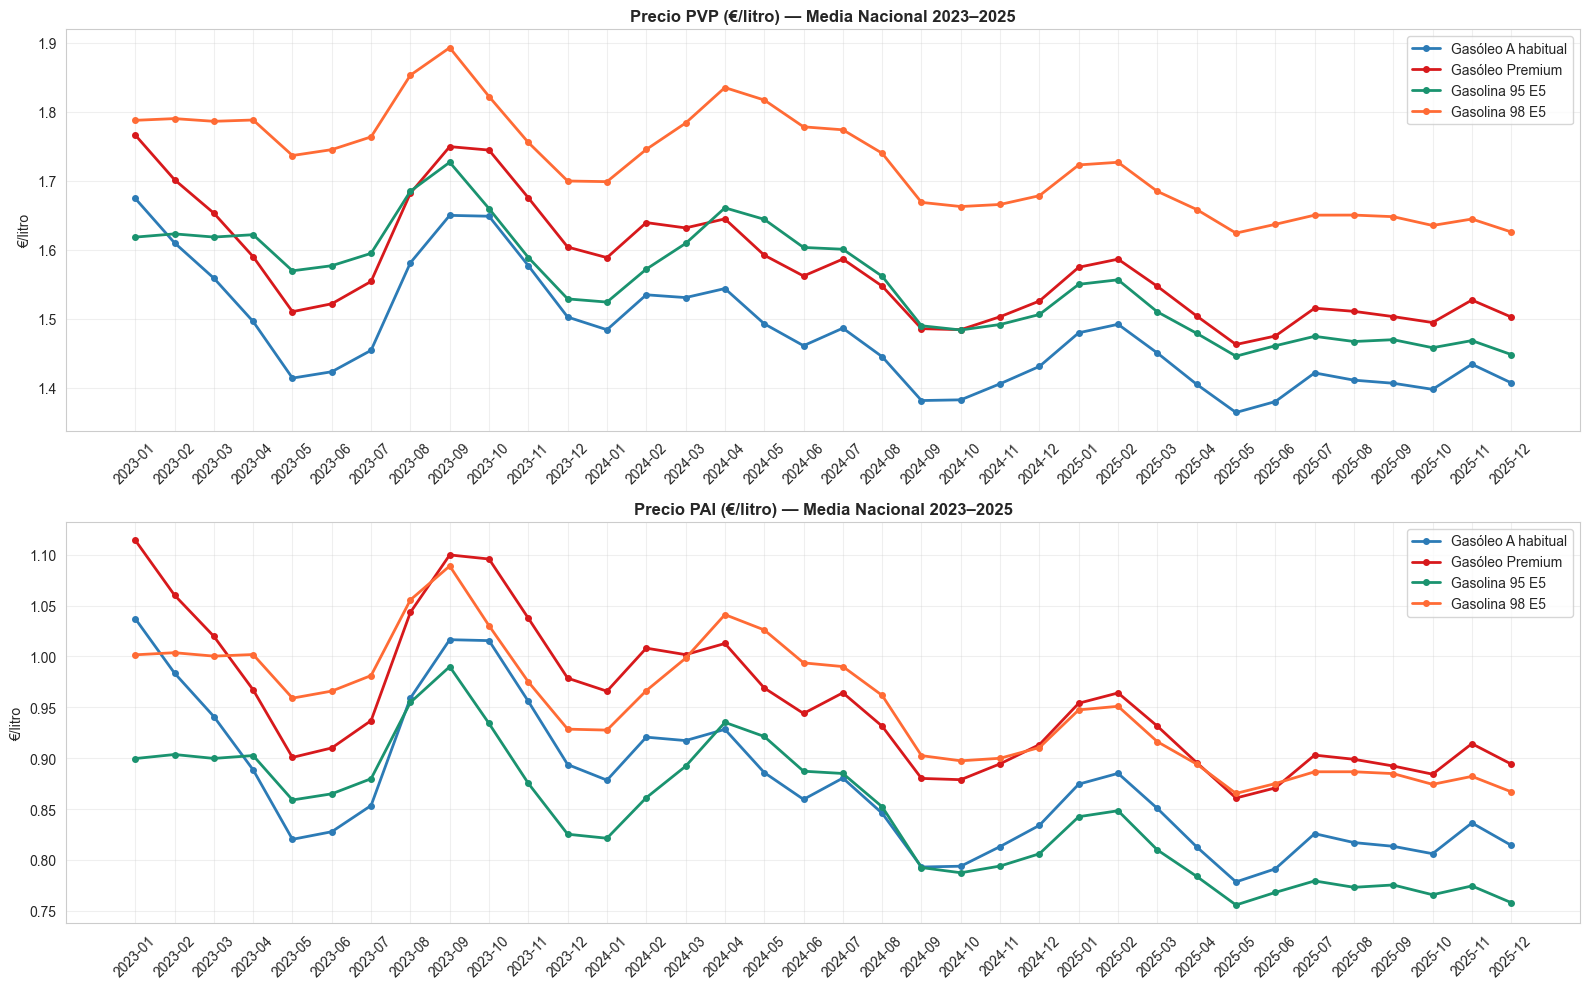

Saved: 12_price_trends.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

products = ['gasoleo_a', 'gasoleo_prem', 'gasolina95', 'gasolina98']
labels   = ['Gasóleo A habitual', 'Gasóleo Premium', 'Gasolina 95 E5', 'Gasolina 98 E5']
colors   = ['#2C7BB6', '#D7191C', '#1A936F', '#FF6B35']

for price_type, ax in zip(['PVP', 'PAI'], axes):
    for prod, lbl, col in zip(products, labels, colors):
        col_name = f'{price_type}_{prod}_nac'
        if col_name not in df_prices.columns:
            continue
        ax.plot(df_prices['Fecha'], df_prices[col_name], color=col, linewidth=2,
                marker='o', markersize=4, label=lbl)
    ax.set_title(f'Precio {price_type} (€/litro) — Media Nacional 2023–2025', fontweight='bold')
    ax.set_ylabel('€/litro')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGS / '12_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_price_trends.png')

## 6. Price ↔ Demand Correlation Analysis

### What?
Test the correlation between monthly fuel prices and monthly biodiesel demand (Nacional + 4 targets).
Include both contemporaneous correlation and lagged correlation (price at t-1 predicting demand at t).

### Why?
If price at t-1 correlates with demand at t, it's a usable lag feature (we know last month's price
when forecasting this month). Contemporaneous correlation is informative but not directly usable
in a real-time forecasting scenario.

In [7]:
master = pd.read_csv(DATA_INPUTS / 'master_dataset.csv')

TARGET_LABEL = {
    'ESPAÑA':               'Nacional',
    'Andalucía':            'Andalucía',
    'Cataluña':             'Cataluña',
    'Madrid, Comunidad de': 'Madrid',
    'Comunitat Valenciana': 'Valencia',
}

df_demand = (
    master[master['Target'] == 1][['Fecha', 'CCAA', 'Consumo_Tm']]
    .copy()
    .assign(Target=lambda d: d['CCAA'].map(TARGET_LABEL))
)

# Merge Nacional demand with national prices
df_nac_demand = df_demand[df_demand['Target'] == 'Nacional'][['Fecha', 'Consumo_Tm']].copy()
df_merged = df_nac_demand.merge(df_prices, on='Fecha', how='inner')

print(f'Merged shape (Nacional × prices): {df_merged.shape}')

# Contemporaneous Pearson correlations (price cols only)
price_cols = [c for c in df_prices.columns if c != 'Fecha' and '_nac' in c]
corr_0 = df_merged[price_cols + ['Consumo_Tm']].corr()['Consumo_Tm'].drop('Consumo_Tm').rename('corr_t0')

# Lagged correlations (price t-1 → demand t)
corr_1 = {}
for c in price_cols:
    shifted = df_merged[c].shift(1)
    corr_1[c] = df_merged['Consumo_Tm'].corr(shifted)
corr_1 = pd.Series(corr_1, name='corr_t-1')

df_corr = pd.concat([corr_0, corr_1], axis=1).sort_values('corr_t0', ascending=False)
print('\nCorrelation with Nacional biodiesel demand:')
print(df_corr.round(3).to_string())

Merged shape (Nacional × prices): (36, 42)

Correlation with Nacional biodiesel demand:
                      corr_t0  corr_t-1
PVP_gasoleo_a_nac      -0.668    -0.689
PAI_gasoleo_a_nac      -0.669    -0.690
PVP_gasoleo_prem_nac   -0.684    -0.703
PAI_gasoleo_prem_nac   -0.688    -0.706
PVP_gasolina98_nac     -0.808    -0.805
PAI_gasolina98_nac     -0.810    -0.806
PVP_gasolina95_nac     -0.815    -0.813
PAI_gasolina95_nac     -0.816    -0.814


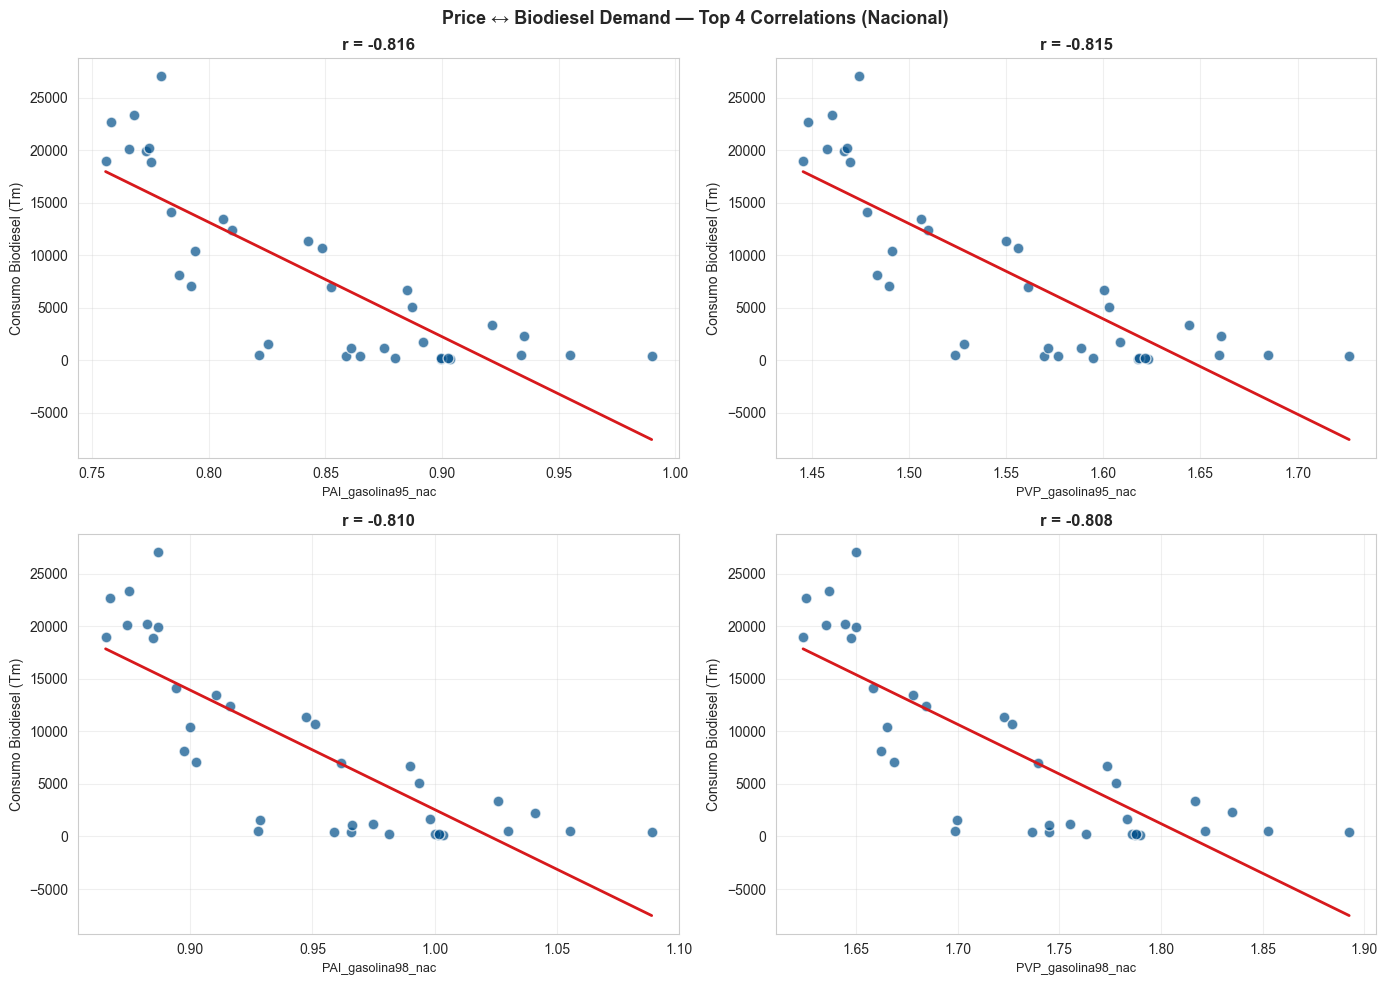

Saved: 13_price_demand_scatter.png


In [8]:
# Visual: scatter plots of top 4 most correlated price features
top4 = df_corr['corr_t0'].abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, top4):
    ax.scatter(df_merged[col], df_merged['Consumo_Tm'],
               color='#004E89', alpha=0.7, edgecolors='white', s=60)
    corr_v = df_merged[col].corr(df_merged['Consumo_Tm'])
    # Trend line
    z = np.polyfit(df_merged[col].dropna(), df_merged.loc[df_merged[col].notna(), 'Consumo_Tm'], 1)
    xfit = np.linspace(df_merged[col].min(), df_merged[col].max(), 50)
    ax.plot(xfit, np.poly1d(z)(xfit), color='#D7191C', linewidth=2)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Consumo Biodiesel (Tm)')
    ax.set_title(f'r = {corr_v:.3f}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Price ↔ Biodiesel Demand — Top 4 Correlations (Nacional)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '13_price_demand_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 13_price_demand_scatter.png')

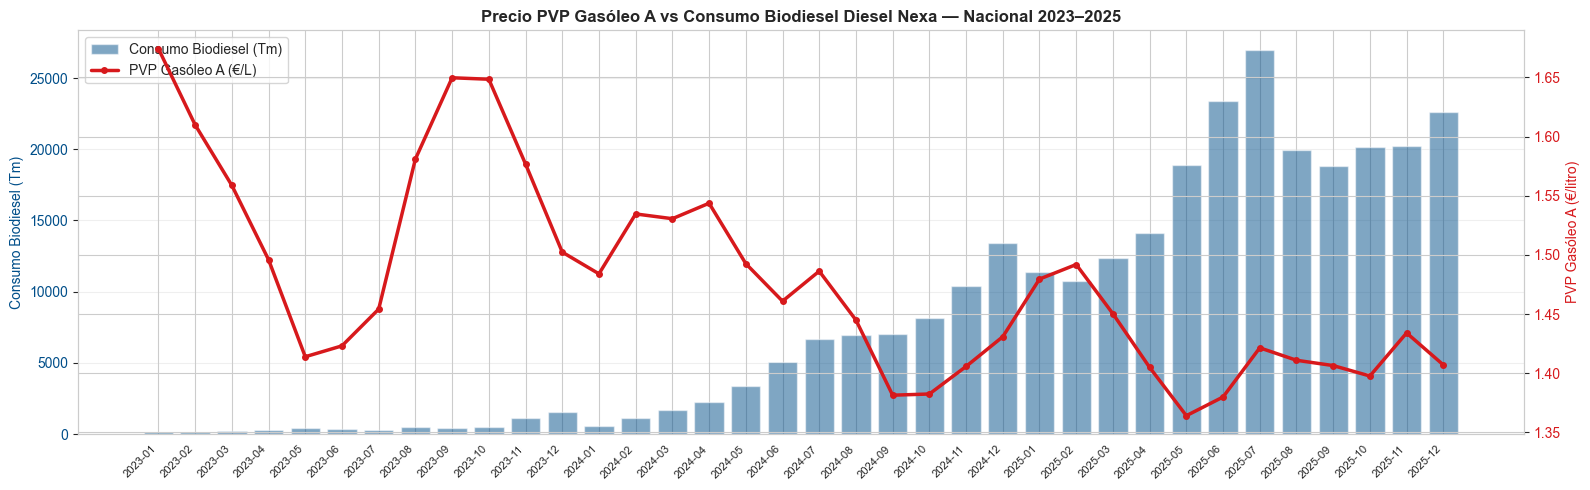

Saved: 14_price_vs_demand_timeline.png


In [9]:
# Dual-axis: precio PVP Gasóleo A vs Consumo Biodiesel over time
fig, ax1 = plt.subplots(figsize=(16, 5))

color_demand = '#004E89'
color_price  = '#D7191C'

ax1.bar(range(len(df_merged)), df_merged['Consumo_Tm'],
        color=color_demand, alpha=0.5, label='Consumo Biodiesel (Tm)')
ax1.set_ylabel('Consumo Biodiesel (Tm)', color=color_demand)
ax1.tick_params(axis='y', labelcolor=color_demand)
ax1.set_xticks(range(len(df_merged)))
ax1.set_xticklabels(df_merged['Fecha'].tolist(), rotation=45, ha='right', fontsize=8)

ax2 = ax1.twinx()
pvp_col = 'PVP_gasoleo_a_nac'
if pvp_col in df_merged.columns:
    ax2.plot(range(len(df_merged)), df_merged[pvp_col],
             color=color_price, linewidth=2.5, marker='o', markersize=4,
             label='PVP Gasóleo A (€/L)')
    ax2.set_ylabel('PVP Gasóleo A (€/litro)', color=color_price)
    ax2.tick_params(axis='y', labelcolor=color_price)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title('Precio PVP Gasóleo A vs Consumo Biodiesel Diesel Nexa — Nacional 2023–2025',
              fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS / '14_price_vs_demand_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 14_price_vs_demand_timeline.png')

## 7. Correlation Heatmap — All Targets × Price Features

Correlation matrix (demand × price features):
          PAI_gasoleo_a  PAI_gasoleo_prem  PAI_gasolina95  PAI_gasolina98  PVP_gasoleo_a  PVP_gasoleo_prem  PVP_gasolina95  PVP_gasolina98
Nacional         -0.669            -0.688          -0.816          -0.810         -0.668            -0.684          -0.815          -0.808
Madrid           -0.698            -0.741          -0.827          -0.789         -0.698            -0.741          -0.827          -0.789
Cataluña         -0.678            -0.690          -0.822          -0.807         -0.678            -0.690          -0.822          -0.807
Valencia         -0.634            -0.632          -0.794          -0.771         -0.634            -0.632          -0.794          -0.771


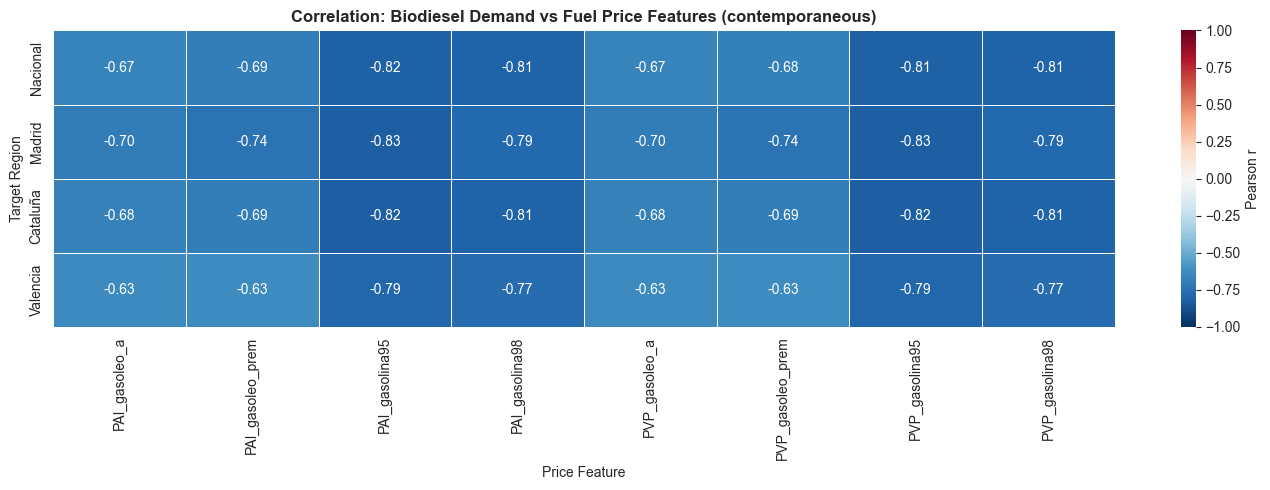

Saved: 15_price_correlation_heatmap.png


In [10]:
TARGET_REGION_PRICE = {
    'Nacional':  '_nac',
    'Madrid':    '_madrid',
    'Cataluña':  '_cataluna',
    'Andalucía': '_andalucia',
    'Valencia':  '_valencia',
}

heatmap_data = {}

for tgt, suffix in TARGET_REGION_PRICE.items():
    demand = df_demand[df_demand['Target'] == tgt][['Fecha','Consumo_Tm']]
    merged = demand.merge(df_prices, on='Fecha', how='inner')
    price_cols_tgt = [c for c in df_prices.columns if c.endswith(suffix)]
    for pc in price_cols_tgt:
        if pc in merged.columns:
            r = merged['Consumo_Tm'].corr(merged[pc])
            short_name = pc.replace(suffix, '')
            heatmap_data.setdefault(tgt, {})[short_name] = round(r, 3)

df_heat = pd.DataFrame(heatmap_data).T
print('Correlation matrix (demand × price features):')
print(df_heat.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation: Biodiesel Demand vs Fuel Price Features (contemporaneous)',
             fontweight='bold')
ax.set_xlabel('Price Feature')
ax.set_ylabel('Target Region')
plt.tight_layout()
plt.savefig(FIGS / '15_price_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_price_correlation_heatmap.png')

## 8. Select Model Features & Add Lag_1

### What?
From the full price matrix, select the features that will be added to the ML model dataset.
We add **lag_1** versions (price at t-1) so they are available at prediction time.

### Why?
A contemporaneous price feature (price at the same month as demand) would require knowing
the price before we observe the demand — valid for modeling but requires price forecasts
in the 24-month forward horizon. A lag_1 feature is causally clean: we always know last
month's price when making a forecast.

In [11]:
# Keep: national prices for all 4 products × both PAI/PVP + regional PVP Gasóleo A
keep_cols = ['Fecha'] + [c for c in df_prices.columns if c != 'Fecha']

df_feat = df_prices[keep_cols].copy().sort_values('Fecha').reset_index(drop=True)

# Add lag_1 for all price columns
price_feature_cols = [c for c in keep_cols if c != 'Fecha']
for c in price_feature_cols:
    df_feat[f'{c}_lag1'] = df_feat[c].shift(1)

print(f'Price features table shape: {df_feat.shape}')
print(f'Columns ({len(df_feat.columns)}): {df_feat.columns.tolist()[:10]} ...')
print(f'\nNull count per column (should be 1 lag row):')
print(df_feat.isnull().sum()[df_feat.isnull().sum() > 0])

Price features table shape: (36, 81)
Columns (81): ['Fecha', 'PAI_gasoleo_a_nac', 'PAI_gasoleo_prem_nac', 'PAI_gasolina95_nac', 'PAI_gasolina98_nac', 'PVP_gasoleo_a_nac', 'PVP_gasoleo_prem_nac', 'PVP_gasolina95_nac', 'PVP_gasolina98_nac', 'PAI_gasoleo_a_madrid'] ...

Null count per column (should be 1 lag row):
PAI_gasoleo_a_nac_lag1             1
PAI_gasoleo_prem_nac_lag1          1
PAI_gasolina95_nac_lag1            1
PAI_gasolina98_nac_lag1            1
PVP_gasoleo_a_nac_lag1             1
PVP_gasoleo_prem_nac_lag1          1
PVP_gasolina95_nac_lag1            1
PVP_gasolina98_nac_lag1            1
PAI_gasoleo_a_madrid_lag1          1
PAI_gasoleo_prem_madrid_lag1       1
PAI_gasolina95_madrid_lag1         1
PAI_gasolina98_madrid_lag1         1
PVP_gasoleo_a_madrid_lag1          1
PVP_gasoleo_prem_madrid_lag1       1
PVP_gasolina95_madrid_lag1         1
PVP_gasolina98_madrid_lag1         1
PAI_gasoleo_a_cataluna_lag1        1
PAI_gasoleo_prem_cataluna_lag1     1
PAI_gasolina95_catalu

## 9. Save

In [12]:
out = DATA_FEATURES / 'features_precios_combustibles.csv'
df_feat.to_csv(out, index=False, encoding='utf-8')

verify = pd.read_csv(out)
print(f'Saved: {out.name}  →  {verify.shape[0]} rows × {verify.shape[1]} cols')
print(verify.head(3).to_string())

Saved: features_precios_combustibles.csv  →  36 rows × 81 cols
     Fecha  PAI_gasoleo_a_nac  PAI_gasoleo_prem_nac  PAI_gasolina95_nac  PAI_gasolina98_nac  PVP_gasoleo_a_nac  PVP_gasoleo_prem_nac  PVP_gasolina95_nac  PVP_gasolina98_nac  PAI_gasoleo_a_madrid  PAI_gasoleo_prem_madrid  PAI_gasolina95_madrid  PAI_gasolina98_madrid  PVP_gasoleo_a_madrid  PVP_gasoleo_prem_madrid  PVP_gasolina95_madrid  PVP_gasolina98_madrid  PAI_gasoleo_a_cataluna  PAI_gasoleo_prem_cataluna  PAI_gasolina95_cataluna  PAI_gasolina98_cataluna  PVP_gasoleo_a_cataluna  PVP_gasoleo_prem_cataluna  PVP_gasolina95_cataluna  PVP_gasolina98_cataluna  PAI_gasoleo_a_andalucía  PAI_gasoleo_prem_andalucía  PAI_gasolina95_andalucía  PAI_gasolina98_andalucía  PVP_gasoleo_a_andalucía  PVP_gasoleo_prem_andalucía  PVP_gasolina95_andalucía  PVP_gasolina98_andalucía  PAI_gasoleo_a_valencia  PAI_gasoleo_prem_valencia  PAI_gasolina95_valencia  PAI_gasolina98_valencia  PVP_gasoleo_a_valencia  PVP_gasoleo_prem_valencia  PVP_gasolina9

## 10. Summary — Should We Retrain?

### Decision criteria
We proceed to retrain the ML models with price features if:
- At least one price feature shows |r| > 0.40 with demand (moderate correlation)
- The lag_1 version also shows |r| > 0.30 (usable for forecasting)

SARIMA does not use price features (SARIMAX with future exogenous values would require
forecasting prices separately — added complexity without clear gain at this sample size).

In [13]:
print('='*65)
print('PRICE ↔ DEMAND CORRELATION SUMMARY (Nacional)')
print('='*65)
print(df_corr.round(3).to_string())

strong_t0 = df_corr[df_corr['corr_t0'].abs() > 0.40]
strong_lag = df_corr[df_corr['corr_t-1'].abs() > 0.30]

print(f'\nFeatures with |r_t0| > 0.40: {len(strong_t0)}')
print(f'Features with |r_lag1| > 0.30: {len(strong_lag)}')

if len(strong_t0) > 0 or len(strong_lag) > 0:
    print('\n✅ RECOMMENDATION: Proceed to 08_modeling_with_prices.ipynb')
    print('   Price features show meaningful correlation — retraining RF + XGBoost is justified.')
else:
    print('\n⚠️  Weak correlation — price features may not improve ML models significantly.')
    print('   Still worth testing (small dataset: correlation ≠ predictive power).')

print('\n' + '='*65)
print('OUTPUT FILES')
print('='*65)
print(f'  data/processed/price_features.csv     {verify.shape}')
print('  reports/figures/12_price_trends.png')
print('  reports/figures/13_price_demand_scatter.png')
print('  reports/figures/14_price_vs_demand_timeline.png')
print('  reports/figures/15_price_correlation_heatmap.png')

PRICE ↔ DEMAND CORRELATION SUMMARY (Nacional)
                      corr_t0  corr_t-1
PVP_gasoleo_a_nac      -0.668    -0.689
PAI_gasoleo_a_nac      -0.669    -0.690
PVP_gasoleo_prem_nac   -0.684    -0.703
PAI_gasoleo_prem_nac   -0.688    -0.706
PVP_gasolina98_nac     -0.808    -0.805
PAI_gasolina98_nac     -0.810    -0.806
PVP_gasolina95_nac     -0.815    -0.813
PAI_gasolina95_nac     -0.816    -0.814

Features with |r_t0| > 0.40: 8
Features with |r_lag1| > 0.30: 8

✅ RECOMMENDATION: Proceed to 08_modeling_with_prices.ipynb
   Price features show meaningful correlation — retraining RF + XGBoost is justified.

OUTPUT FILES
  data/processed/price_features.csv     (36, 81)
  reports/figures/12_price_trends.png
  reports/figures/13_price_demand_scatter.png
  reports/figures/14_price_vs_demand_timeline.png
  reports/figures/15_price_correlation_heatmap.png
